<a href="https://colab.research.google.com/github/yoradzasky/2025-Computer_Vision-TI2B/blob/main/Jobsheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## D1- PRAKTIKUM

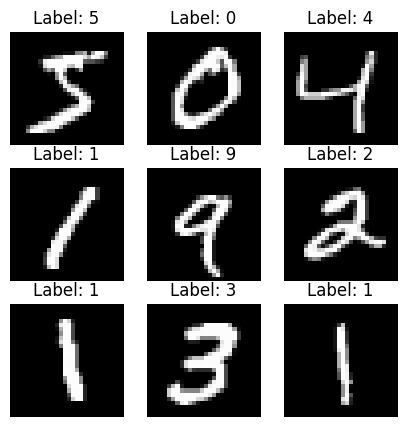

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
 plt.subplot(3,3,i+1)
 plt.imshow(x_train[i], cmap='gray')
 plt.title(f"Label: {y_train[i]}")
 plt.axis('off')
plt.show()


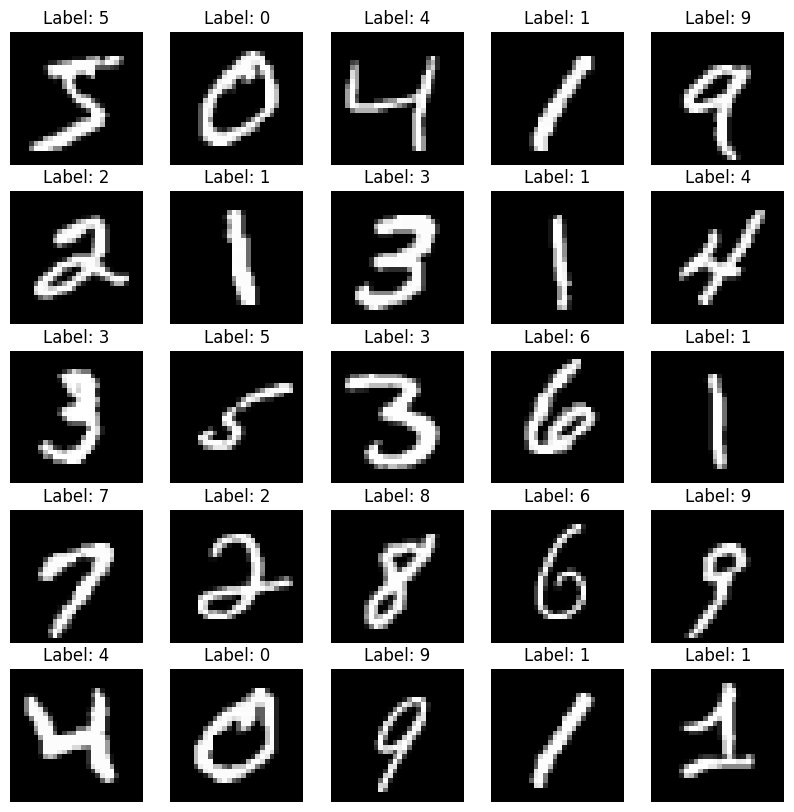

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(10,10)) # Increased figure size for better visualization
for i in range(25):
    plt.subplot(5,5,i+1) # Changed subplot grid to 5x5
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

## D2-PRAKTIKUM

In [3]:
from sklearn import svm
from sklearn.metrics import accuracy_score
# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0
# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)
print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


## D3-PRAKTIKUM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.8979 - loss: 0.3463 - val_accuracy: 0.9812 - val_loss: 0.0687
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9804 - loss: 0.0647 - val_accuracy: 0.9838 - val_loss: 0.0560
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9874 - loss: 0.0404 - val_accuracy: 0.9873 - val_loss: 0.0487
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9919 - loss: 0.0258 - val_accuracy: 0.9832 - val_loss: 0.0674
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.9875 - val_loss: 0.0528


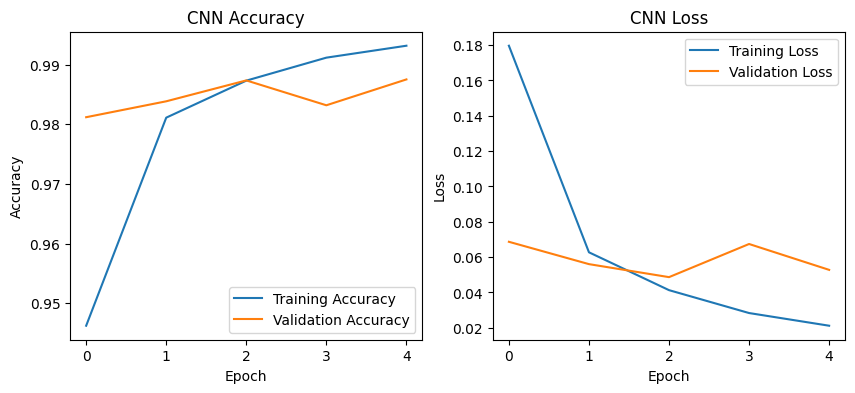

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ===== Preprocessing =====
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# ===== Bangun CNN =====
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name="Conv1"),
    layers.MaxPooling2D((2,2), name="Pool1"),
    layers.Flatten(name="Flatten"),
    layers.Dense(64, activation='relu', name="Dense1"),
    layers.Dense(10, activation='softmax', name="Output")
])

# ===== Compile =====
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# ===== Training =====
history = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

# ===== Plot History =====
plt.figure(figsize=(10,4))

# Plot Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 53s 122ms/step - accuracy: 0.8452 - loss: 0.4970 - val_accuracy: 0.9820 - val_loss: 0.0634
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9740 - loss: 0.0897 - val_accuracy: 0.9898 - val_loss: 0.0396
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.9821 - loss: 0.0618 - val_accuracy: 0.9897 - val_loss: 0.0358
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9903 - val_loss: 0.0371
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9902 - val_loss: 0.0334


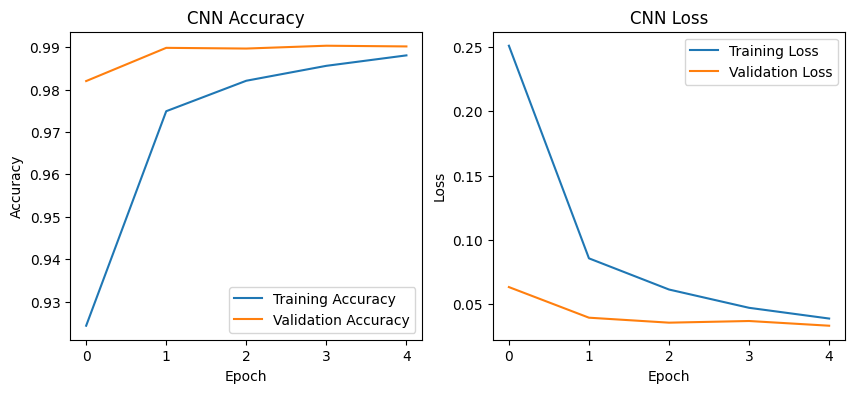

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ===== Preprocessing =====
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# ===== Bangun CNN =====
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name="Conv1"),
    layers.MaxPooling2D((2,2), name="Pool1"),
    layers.Conv2D(64, (3,3), activation='relu', name="Conv2"),   # Tambahan Conv Layer
    layers.Flatten(name="Flatten"),
    layers.Dense(128, activation='relu', name="Dense1"),
    layers.Dropout(0.5, name="Dropout"),                        # Dropout untuk cegah overfitting
    layers.Dense(10, activation='softmax', name="Output")
])

# ===== Compile =====
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# ===== Training =====
history = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ===== Plot History =====
plt.figure(figsize=(10,4))

# Plot Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## D4-PRAKTIKUM

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 45ms/step - accuracy: 0.3792 - loss: 1.6948 - val_accuracy: 0.5924 - val_loss: 1.1631
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.5987 - loss: 1.1405 - val_accuracy: 0.6130 - val_loss: 1.1033
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.6507 - loss: 1.0041 - val_accuracy: 0.6492 - val_loss: 1.0096
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.6868 - loss: 0.8954 - val_accuracy: 0.6648 - val_loss: 0.9519
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.7074 - loss: 0.8338 - val_accuracy: 0.6514 - val_loss: 0.9921
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - accuracy: 0.7326 - loss: 0.7647 - val_accuracy: 0.6988 - val_loss: 0.8981
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.7524 - loss: 0.7088 - val_accuracy: 0.6984 - val_loss: 0.8845
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.7704 -

''

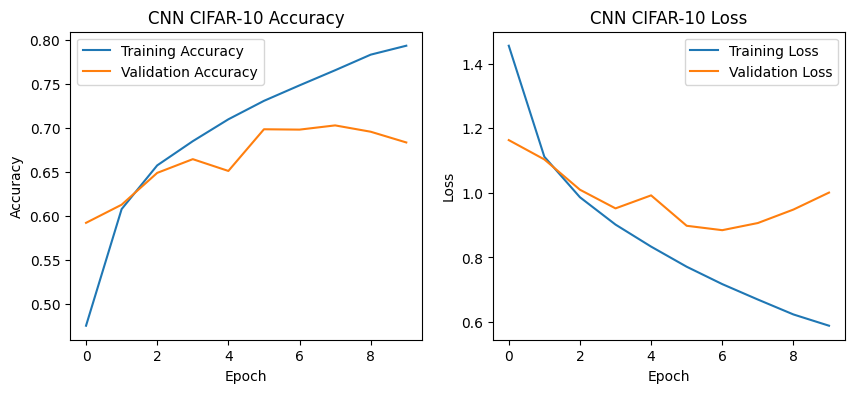

In [37]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
model = models.Sequential([
 layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),  layers.MaxPooling2D((2,2)),
 layers.Conv2D(64, (3,3), activation='relu'),
 layers.MaxPooling2D((2,2)),
 layers.Flatten(),
 layers.Dense(64, activation='relu'),
 layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)
# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
""

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 619s 439ms/step - accuracy: 0.4653 - loss: 1.5450 - val_accuracy: 0.5580 - val_loss: 1.2398
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 644s 455ms/step - accuracy: 0.5767 - loss: 1.2071 - val_accuracy: 0.5760 - val_loss: 1.1994
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 680s 454ms/step - accuracy: 0.5985 - loss: 1.1415 - val_accuracy: 0.5990 - val_loss: 1.1339
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 680s 453ms/step - accuracy: 0.6205 - loss: 1.0973 - val_accuracy: 0.6110 - val_loss: 1.1147
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 680s 452ms/step - accuracy: 0.6253 - loss: 1.0647 - val_accuracy: 0.6058 - val_loss: 1.1155


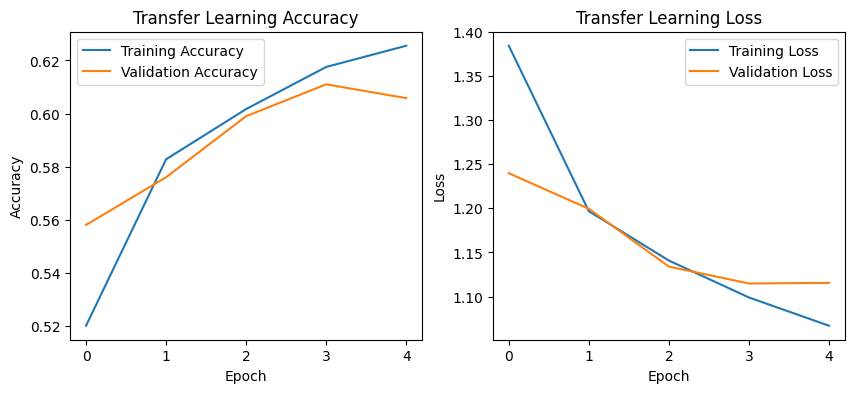

In [38]:
 from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False,  input_shape=(32,32,3))
base_model.trainable = False
model = models.Sequential([
 base_model,
 layers.Flatten(),
 layers.Dense(128, activation='relu'),
 layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)
# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## D5-PRAKTIKUM

In [39]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# Freeze semua dulu
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model = models.Sequential([

    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)
# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2498s 2s/step - accuracy: 0.5074 - loss: 1.3857 - val_accuracy: 0.6594 - val_loss: 1.0650
Epoch 2/5
 561/1407 ━━━━━━━━━━━━━━━━━━━━ 24:21 2s/step - accuracy: 0.7092 - loss: 0.8518

KeyboardInterrupt: 

## D6-PRAKTIKUM

In [ ]:
z   from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === Prediksi ===
y_pred = model.predict(x_test).argmax(axis=1)

# === Classification Report ===
print("Classification Report:")
print(classification_report(y_test, y_pred))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


##Penugasan


### PRE-PROCESS

In [9]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload()  # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
    - Konversi ke grayscale
    - Auto-contrast
    - (Opsional) invert bila latar terang (agar digit jadi putih di atas latar gelap seperti MNIST)
    - Crop ke bounding box digit
    - Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    - Normalisasi ke [0,1] dan tambah axis channel
    """
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    # Jika rata-rata terang (kertas putih), invert supaya digit jadi putih di atas latar gelap
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8  # ambang adaptif sederhana
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1 + 1, y1 + 1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w) // 2, (28 - h) // 2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0

    # Tambah channel dim (28,28,1)
    arr = arr[..., None]

    return canvas, arr

def preprocess_to_cifar10_32x32(img_pil):
    """
    Langkah:
    - Resize ke 32x32 (dengan antialias)
    - Konversi ke RGB (3 channel)
    - Normalisasi ke [0,1]
    """
    img = img_pil.resize((32, 32), Image.Resampling.LANCZOS)
    img = img.convert('RGB')
    arr = np.array(img).astype('float32') / 255.0
    return img, arr

Saving js2.jpg to js2 (1).jpg


### Prediksi dengan SVM

In [10]:
from sklearn.metrics import accuracy_score

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    _, x = preprocess_to_mnist_28x28(img_pil)   # x: (28,28,1) float [0,1]

    # Flatten ke (1, 784) untuk SVM
    x_flat = x.reshape(1, -1)

    # Prediksi dengan model SVM (clf sudah dilatih sebelumnya)
    pred = int(clf.predict(x_flat)[0])

    # Ambil probabilitas (jika SVC dilatih dengan probability=True)
    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    # Simpan hasil
    results.append((fname, pred, conf))

    # Print hasil prediksi
    if conf is not None:
        print(f"{fname} -> Prediksi SVM: {pred} (p≈{conf:.2f})")
    else:
        print(f"{fname} -> Prediksi SVM: {pred}")

js2 (1).jpg -> Prediksi SVM: 2
